In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.feature_selection import SelectFromModel, RFE, f_regression, mutual_info_regression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from scipy.stats import pearsonr, spearmanr
from statsmodels.stats.outliers_influence import variance_inflation_factor
import warnings

warnings.filterwarnings('ignore')
plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

print("✓ 所有库导入完成")

✓ 所有库导入完成


In [26]:
# 第一步：数据加载与初步探索
print("="*80)
print("第一步：数据加载与初步探索")
print("="*80)

# 读取 Excel 文件
try:
    df = pd.read_excel('CO2_capacity.xlsx', engine='openpyxl')
    print(f"✓ 成功读取数据，形状：{df.shape}")
except Exception as e:
    raise RuntimeError(f"读取失败：{e}")

# 基本信息
print(f"\n数据基本信息：")
print(f"  • 行数：{len(df)}")
print(f"  • 列数：{len(df.columns)}")
print(f"  • 列名：{list(df.columns)[:5]}... (共{len(df.columns)}列)")

# 确定目标列与特征列
first_col = df.columns[0]  # 假设第一列为 ID/时间
target_col = df.columns[-1]  # 最后一列为目标
feature_cols = df.columns[1:-1]  # 中间列为特征

print(f"\n列角色定义：")
print(f"  • ID/索引列：{first_col}")
print(f"  • 目标列：{target_col}")
print(f"  • 特征列数：{len(feature_cols)}")

# 提取 X 和 y
X = df[feature_cols].copy()
y = df[target_col].copy()

print(f"\n目标变量统计：")
print(f"  • 数据类型：{y.dtype}")
print(f"  • 非空值：{y.notna().sum()}/{len(y)}")
print(f"  • 最小值：{y.min():.6f}")
print(f"  • 最大值：{y.max():.6f}")
print(f"  • 平均值：{y.mean():.6f}")
print(f"  • 标准差：{y.std():.6f}")

第一步：数据加载与初步探索
✓ 成功读取数据，形状：(10080, 59)

数据基本信息：
  • 行数：10080
  • 列数：59
  • 列名：['Date', 'PI-2', 'TI-2', 'FI-2', 'PI-3']... (共59列)

列角色定义：
  • ID/索引列：Date
  • 目标列：CO2 capacity
  • 特征列数：57

目标变量统计：
  • 数据类型：float64
  • 非空值：10080/10080
  • 最小值：0.416014
  • 最大值：1.000707
  • 平均值：0.874542
  • 标准差：0.062135
✓ 成功读取数据，形状：(10080, 59)

数据基本信息：
  • 行数：10080
  • 列数：59
  • 列名：['Date', 'PI-2', 'TI-2', 'FI-2', 'PI-3']... (共59列)

列角色定义：
  • ID/索引列：Date
  • 目标列：CO2 capacity
  • 特征列数：57

目标变量统计：
  • 数据类型：float64
  • 非空值：10080/10080
  • 最小值：0.416014
  • 最大值：1.000707
  • 平均值：0.874542
  • 标准差：0.062135



第四步：多方法综合相关性评估

评估方法说明：
  1. Pearson 相关系数：线性相关强度，范围 [-1, 1]
  2. Spearman 秩相关：单调相关强度，对异常值鲁棒
  3. 互信息（MI）：非线性关系强度，基于信息论
  4. 综合评分：(|Pearson| + |Spearman|) / 2 的平均


【Top 15 相关特征（按综合评分排序）】
    特征  Pearson_r  Spearman_rho  MutualInfo     综合评分
 TI-34   0.807710      0.730693    1.360465 0.709553
 TI-33   0.597697      0.604605    1.280509 0.556956
 TI-24   0.537427      0.428390    1.162745 0.430799
 FI-38   0.471404      0.383862    0.492129 0.379110
 TI-32   0.462722      0.352018    1.102212 0.359188
TI-242   0.523410      0.301289    1.170383 0.354607
 TI-25   0.451149      0.336035    1.065933 0.347967
 TI-30   0.479549      0.284752    1.078688 0.326316
 FI-36   0.403856      0.307540    0.332848 0.311190
 FI-30   0.474879      0.249319    0.595123 0.306250
  PI-4  -0.186835     -0.369190    0.582077 0.272417
  O2-3   0.275333      0.303345    0.484370 0.266838
  TI-7   0.435370     -0.162274    0.378146 0.236871
 TI-12   0.075823      0.350628    0.970248 0.228513
 PI-30  -0.137594

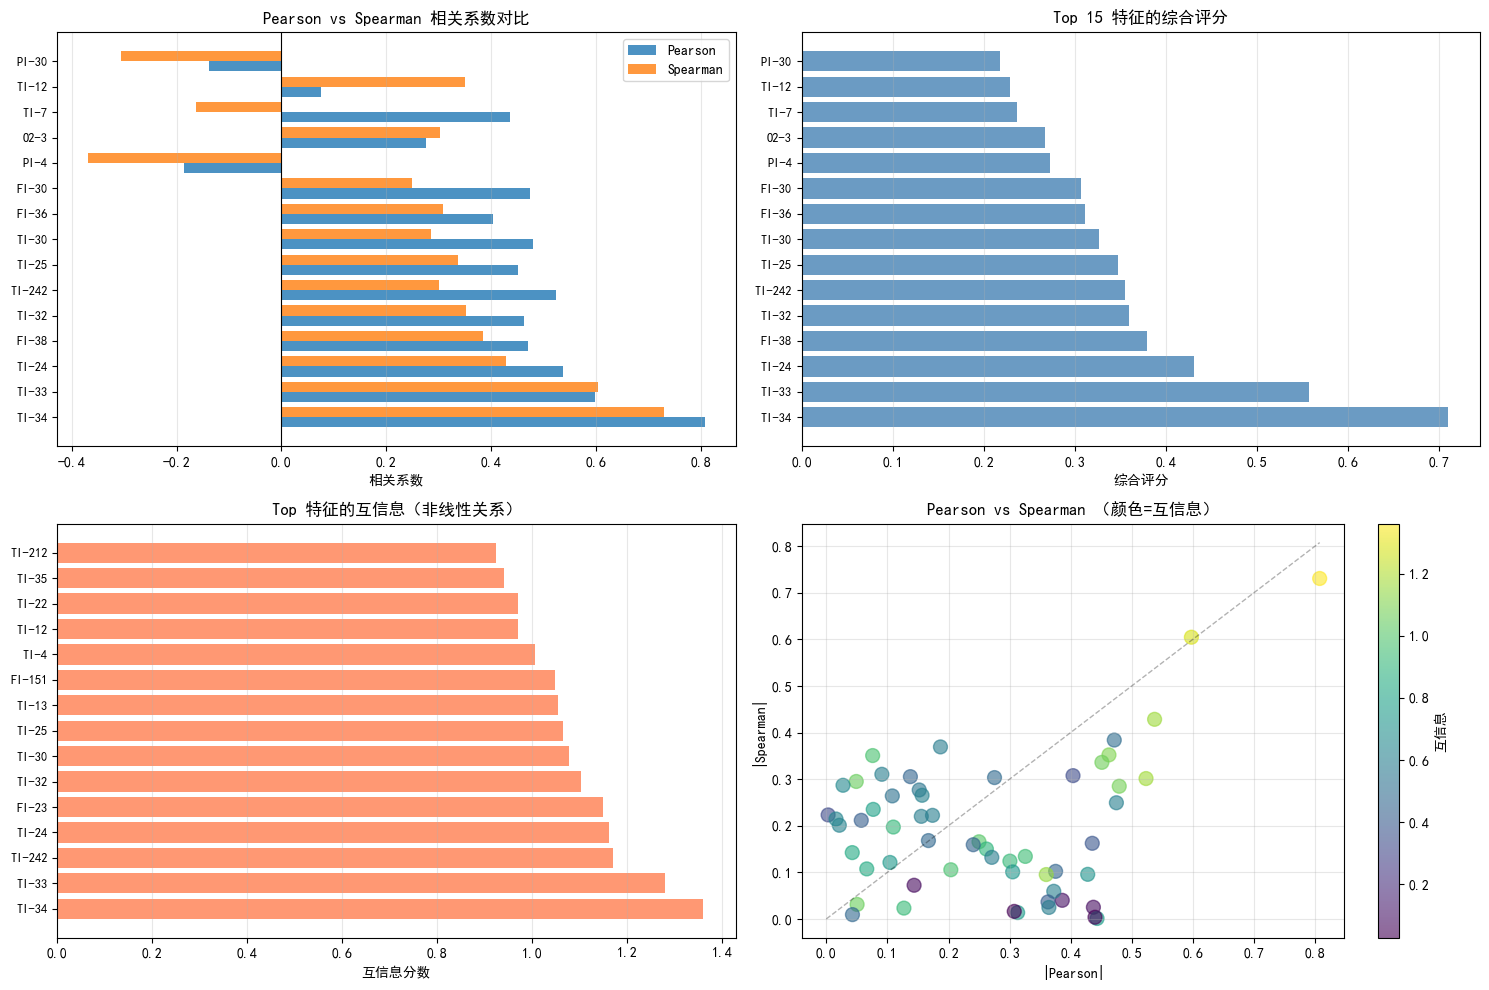

✓ 已保存图表为 'comprehensive_correlation_methods_comparison.png'


In [33]:
# 第四步：多方法综合相关性评估
print("\n" + "="*80)
print("第四步：多方法综合相关性评估")
print("="*80)

print("""
评估方法说明：
  1. Pearson 相关系数：线性相关强度，范围 [-1, 1]
  2. Spearman 秩相关：单调相关强度，对异常值鲁棒
  3. 互信息（MI）：非线性关系强度，基于信息论
  4. 综合评分：(|Pearson| + |Spearman|) / 2 的平均
""")

from scipy.stats import kendalltau
from sklearn.feature_selection import mutual_info_regression

# 计算多种相关系数
corr_results = []

for col in X_numeric.columns:
    # 1. Pearson 相关系数
    pearson_r, pearson_p = pearsonr(X_numeric[col], y_numeric)
    
    # 2. Spearman 秩相关系数
    spearman_r, spearman_p = spearmanr(X_numeric[col], y_numeric)
    
    # 3. Kendall Tau（作为补充，更稳健）
    kendall_tau, kendall_p = kendalltau(X_numeric[col], y_numeric)
    
    # 4. 互信息（捕捉非线性关系）
    try:
        mi_score = mutual_info_regression(
            X_numeric[[col]], y_numeric, random_state=42
        )[0]
    except:
        mi_score = np.nan
    
    # 综合评分：取三个秩相关方法的绝对值平均
    combined_score = (abs(pearson_r) + abs(spearman_r) + abs(kendall_tau)) / 3
    
    corr_results.append({
        '特征': col,
        'Pearson_r': pearson_r,
        'Pearson_p': pearson_p,
        'Spearman_rho': spearman_r,
        'Spearman_p': spearman_p,
        'Kendall_tau': kendall_tau,
        'Kendall_p': kendall_p,
        'MutualInfo': mi_score,
        '综合评分': combined_score,
        'abs_Pearson': abs(pearson_r)
    })

# 创建结果 DataFrame
corr_df = pd.DataFrame(corr_results).sort_values('综合评分', ascending=False)

# 打印 Top 15 特征
print("\n【Top 15 相关特征（按综合评分排序）】")
print(corr_df[['特征', 'Pearson_r', 'Spearman_rho', 'MutualInfo', '综合评分']].head(15).to_string(index=False))

# 打印详细的相关系数表（前 10）
print("\n【前 10 特征的详细相关性分析】")
top_10_df = corr_df[['特征', 'Pearson_r', 'Spearman_rho', 'Kendall_tau', 'MutualInfo']].head(10)
print(top_10_df.to_string(index=False))

# 统计分析
print(f"\n【相关性统计分析】")
print(f"  • 强相关（|r| > 0.7）特征数：{(corr_df['abs_Pearson'] > 0.7).sum()}")
print(f"  • 中等相关（0.5 < |r| < 0.7）特征数：{((corr_df['abs_Pearson'] > 0.5) & (corr_df['abs_Pearson'] <= 0.7)).sum()}")
print(f"  • 弱相关（0.3 < |r| < 0.5）特征数：{((corr_df['abs_Pearson'] > 0.3) & (corr_df['abs_Pearson'] <= 0.5)).sum()}")
print(f"  • 几乎无相关（|r| ≤ 0.3）特征数：{(corr_df['abs_Pearson'] <= 0.3).sum()}")

# 按综合评分筛选特征
CORR_THRESHOLD = 0.3  # 综合评分阈值
high_corr_features = corr_df[corr_df['综合评分'] > CORR_THRESHOLD]['特征'].tolist()

print(f"\n【特征筛选结果】")
print(f"  • 综合评分 > {CORR_THRESHOLD} 的特征数：{len(high_corr_features)}")
print(f"  • 筛选后特征列表：{high_corr_features}")

# 保存相关性分析结果
try:
    corr_df.to_csv('comprehensive_correlation_analysis.csv', index=False, encoding='utf-8-sig')
    print(f"\n✓ 已保存相关性分析结果为 'comprehensive_correlation_analysis.csv'")
except Exception as e:
    print(f"\n⚠ 保存失败：{e}")

# 可视化相关系数对比
print("\n【生成相关系数对比图表】")
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 图 1：Pearson vs Spearman 对比
ax1 = axes[0, 0]
top_n = 15
top_features = corr_df.head(top_n)
x_pos = np.arange(len(top_features))
ax1.barh(x_pos - 0.2, top_features['Pearson_r'], 0.4, label='Pearson', alpha=0.8)
ax1.barh(x_pos + 0.2, top_features['Spearman_rho'], 0.4, label='Spearman', alpha=0.8)
ax1.set_yticks(x_pos)
ax1.set_yticklabels(top_features['特征'], fontsize=9)
ax1.set_xlabel('相关系数', fontweight='bold')
ax1.set_title('Pearson vs Spearman 相关系数对比', fontweight='bold')
ax1.legend()
ax1.axvline(0, color='black', linestyle='-', linewidth=0.8)
ax1.grid(axis='x', alpha=0.3)

# 图 2：综合评分排序
ax2 = axes[0, 1]
colors = ['red' if x < 0 else 'green' for x in top_features['Pearson_r']]
ax2.barh(range(len(top_features)), top_features['综合评分'], color='steelblue', alpha=0.8)
ax2.set_yticks(range(len(top_features)))
ax2.set_yticklabels(top_features['特征'], fontsize=9)
ax2.set_xlabel('综合评分', fontweight='bold')
ax2.set_title(f'Top {top_n} 特征的综合评分', fontweight='bold')
ax2.grid(axis='x', alpha=0.3)

# 图 3：互信息（非线性关系）
ax3 = axes[1, 0]
top_mi = corr_df.nlargest(top_n, 'MutualInfo')
ax3.barh(range(len(top_mi)), top_mi['MutualInfo'], color='coral', alpha=0.8)
ax3.set_yticks(range(len(top_mi)))
ax3.set_yticklabels(top_mi['特征'], fontsize=9)
ax3.set_xlabel('互信息分数', fontweight='bold')
ax3.set_title('Top 特征的互信息（非线性关系）', fontweight='bold')
ax3.grid(axis='x', alpha=0.3)

# 图 4：散点图 - 三方法对比
ax4 = axes[1, 1]
scatter = ax4.scatter(
    corr_df['abs_Pearson'], 
    corr_df['Spearman_rho'].abs(),
    c=corr_df['MutualInfo'],
    s=100,
    alpha=0.6,
    cmap='viridis'
)
ax4.set_xlabel('|Pearson|', fontweight='bold')
ax4.set_ylabel('|Spearman|', fontweight='bold')
ax4.set_title('Pearson vs Spearman （颜色=互信息）', fontweight='bold')
cbar = plt.colorbar(scatter, ax=ax4)
cbar.set_label('互信息', fontweight='bold')
ax4.grid(alpha=0.3)

# 添加对角线（相等线）
lims = [0, max(corr_df['abs_Pearson'].max(), corr_df['Spearman_rho'].abs().max())]
ax4.plot(lims, lims, 'k--', alpha=0.3, linewidth=1)

plt.tight_layout()
plt.savefig('comprehensive_correlation_methods_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ 已保存图表为 'comprehensive_correlation_methods_comparison.png'")


In [ ]:
# 第六步：基于模型的特征选择
print("\n" + "="*80)
print("第六步：基于模型的特征选择")
print("="*80)

# 准备数据：标准化
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_numeric)
X_scaled = pd.DataFrame(X_scaled, columns=X_numeric.columns)

# 方法 1：Tree-based Feature Importance
print("\n方法 1：基于 RandomForest 的特征重要性")
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_scaled, y_numeric)

feature_importance = pd.DataFrame({
    '特征': X_numeric.columns,
    '重要性': rf.feature_importances_
}).sort_values('重要性', ascending=False)

print("\nTop 10 重要特征：")
print(feature_importance.head(10).to_string(index=False))

# SelectFromModel - 保留重要性 > 0.01 的特征
selector = SelectFromModel(rf, threshold=0.01, prefit=True)
selected_mask = selector.get_support()
features_rf_selected = X_numeric.columns[selected_mask].tolist()

print(f"\n  • SelectFromModel（threshold=0.01）选出特征数：{len(features_rf_selected)}")
print(f"  • 选出的特征：{features_rf_selected}")

# 方法 2：RFE（递归特征消除）- 选择 Top 50% 特征
print("\n方法 2：RFE（递归特征消除）")
n_features_to_select = max(1, len(X_numeric.columns) // 2)
rfe = RFE(LinearRegression(), n_features_to_select=n_features_to_select, step=1)
rfe.fit(X_scaled, y_numeric)
features_rfe_selected = X_numeric.columns[rfe.support_].tolist()

print(f"  • RFE 选出特征数：{n_features_to_select}")
print(f"  • 选出的特征：{features_rfe_selected}")


第六步：基于模型的特征选择

方法 1：基于 RandomForest 的特征重要性

Top 10 重要特征：
            特征      重要性
         TI-34 0.646753
Level Desorber 0.072964
         FI-23 0.071989
          PI-4 0.040343
         TI-35 0.023601
         TI-36 0.012588
         TI-19 0.011279
          TI-3 0.010216
        TI-35b 0.008105
          TI-8 0.005172

  • SelectFromModel（threshold='median'）选出特征数：29
  • 选出的特征：['TI-2', 'PI-3', 'TI-3', 'O2-3', 'TI-34', 'TI-35', 'PI-4', 'TI-4', 'NH3-4', 'TI-12', 'FI-20', 'TI-8', 'TI-5', 'TI-7', 'TI-28', 'TI-30', 'TI-36', 'TI-19', 'TI-1', 'TI-35b', 'FI-23', 'TI-22', 'Level Desorber', 'Level Reboiler', 'FI-16', 'TI-16', 'FI-151', 'TI-152', 'TI-212']

方法 2：RFE（递归特征消除）

Top 10 重要特征：
            特征      重要性
         TI-34 0.646753
Level Desorber 0.072964
         FI-23 0.071989
          PI-4 0.040343
         TI-35 0.023601
         TI-36 0.012588
         TI-19 0.011279
          TI-3 0.010216
        TI-35b 0.008105
          TI-8 0.005172

  • SelectFromModel（threshold='median'）选出特征数：29


In [36]:
# 第七步：综合特征选择与模型性能对比
print("\n" + "="*80)
print("第七步：综合特征选择与模型性能对比")
print("="*80)

# 定义多个特征集合
feature_sets = {
    '全部特征': X_numeric.columns.tolist(),
    '高相关特征': features_after_vif,
    'RF_SelectFromModel': features_rf_selected,
    'RFE': features_rfe_selected,
    '交集（推荐）': list(set(features_after_vif) & set(features_rf_selected) & set(features_rfe_selected))
}

# 移除空集
feature_sets = {k: v for k, v in feature_sets.items() if len(v) > 0}

# 对每个特征集训练模型并评估
results = []
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

print("\n用 5-fold CV 评估各特征集的模型性能...\n")

for set_name, features in feature_sets.items():
    if len(features) == 0:
        continue
    
    X_subset = X_scaled[features]
    
    # 用 RandomForest 作为默认模型
    model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
    
    # 交叉验证
    cv_r2 = cross_val_score(model, X_subset, y_numeric, cv=kfold, scoring='r2', n_jobs=-1)
    cv_rmse = np.sqrt(-cross_val_score(model, X_subset, y_numeric, cv=kfold, scoring='neg_mean_squared_error', n_jobs=-1))
    cv_mae = -cross_val_score(model, X_subset, y_numeric, cv=kfold, scoring='neg_mean_absolute_error', n_jobs=-1)
    
    results.append({
        '特征集': set_name,
        '特征数': len(features),
        'R²_mean': cv_r2.mean(),
        'R²_std': cv_r2.std(),
        'RMSE_mean': cv_rmse.mean(),
        'RMSE_std': cv_rmse.std(),
        'MAE_mean': cv_mae.mean()
    })

results_df = pd.DataFrame(results)
print("性能对比（5-Fold CV）：")
print(results_df.to_string(index=False))

# 找到最优特征集
best_idx = results_df['R²_mean'].idxmax()
best_set_name = results_df.loc[best_idx, '特征集']
best_features = feature_sets[best_set_name]

print(f"\n✓ 推荐最优特征集：{best_set_name}（R²: {results_df.loc[best_idx, 'R²_mean']:.4f}）")
print(f"\n最优特征列表（共 {len(best_features)} 个）：")
for i, feat in enumerate(best_features, 1):
    print(f"  {i}. {feat}")


第七步：综合特征选择与模型性能对比

用 5-fold CV 评估各特征集的模型性能...

性能对比（5-Fold CV）：
               特征集  特征数  R²_mean   R²_std  RMSE_mean  RMSE_std  MAE_mean
              全部特征   57 0.979623 0.006320   0.008760  0.001594  0.002726
RF_SelectFromModel   29 0.980946 0.006911   0.008418  0.001715  0.002583
               RFE   28 0.981425 0.006868   0.008315  0.001772  0.002679

✓ 推荐最优特征集：RFE（R²: 0.9814）

最优特征列表（共 28 个）：
  1. TI-2
  2. FI-2
  3. PI-3
  4. TI-3
  5. TI-32
  6. TI-33
  7. TI-34
  8. TI-35
  9. TI-4
  10. TI-12
  11. TI-13
  12. TI-8
  13. TI-9
  14. TI-5
  15. PI-30
  16. TI-30
  17. FI-30
  18. PI-38
  19. TI-36
  20. TI-39
  21. Level Reboiler
  22. TI-24
  23. FI-16
  24. FI-151
  25. TI-151
  26. TI-152
  27. TI-212
  28. TI-242
性能对比（5-Fold CV）：
               特征集  特征数  R²_mean   R²_std  RMSE_mean  RMSE_std  MAE_mean
              全部特征   57 0.979623 0.006320   0.008760  0.001594  0.002726
RF_SelectFromModel   29 0.980946 0.006911   0.008418  0.001715  0.002583
               RFE   28 0.9814

In [38]:
# 第九步：输出与保存
print("\n" + "="*80)
print("第九步：输出与保存")
print("="*80)

# 汇总输出
summary = f"""
特征工程与选择总结
═══════════════════════════════════════════════════════════════════════════════

【初始数据】
  • 原始样本数：{len(df)}
  • 原始特征数：{len(X_numeric.columns)}
  • 目标列：{target_col}

【筛选过程】
  1. 初筛（缺失率 > {MISSING_THRESHOLD*100}%）：删除 {len(to_drop_initial)} 个特征
  2. 相关性筛选（|Pearson| > {CORR_THRESHOLD}）：保留 {len(high_corr_features)} 个特征
  3. VIF 检查（VIF ≤ {VIF_THRESHOLD}）：保留 {len(features_after_vif)} 个特征
  4. SelectFromModel：选出 {len(features_rf_selected)} 个特征
  5. RFE：选出 {len(features_rfe_selected)} 个特征

【最优特征集】
  • 特征集名称：{best_set_name}
  • 特征数：{len(best_features)}
  • CV 平均 R²：{results_df.loc[best_idx, 'R²_mean']:.4f}
  • 特征列表：{best_features}

【最优模型】
  • 模型类型：{best_model_name}
  • 测试 R²：{final_df.loc[best_model_idx, '测试R²']:.4f}
  • 测试 RMSE：{final_df.loc[best_model_idx, '测试RMSE']:.4f}
  • 测试 MAE：{final_df.loc[best_model_idx, '测试MAE']:.4f}

═══════════════════════════════════════════════════════════════════════════════
"""

print(summary)

# 保存特征集合与结果
feature_summary = {
    '特征集': best_set_name,
    '特征': best_features,
    '特征数': len(best_features),
    'CV_R2_mean': results_df.loc[best_idx, 'R²_mean'],
    'CV_R2_std': results_df.loc[best_idx, 'R²_std'],
    '最优模型': best_model_name,
    '测试R2': final_df.loc[best_model_idx, '测试R²'],
    '测试RMSE': final_df.loc[best_model_idx, '测试RMSE']
}

# 保存为 CSV
try:
    results_df.to_csv('feature_selection_comparison.csv', index=False, encoding='utf-8-sig')
    final_df.to_csv('model_performance_comparison.csv', index=False, encoding='utf-8-sig')
    print("\n✓ 已保存：")
    print("  • feature_selection_comparison.csv")
    print("  • model_performance_comparison.csv")
except Exception as e:
    print(f"⚠ 保存失败：{e}")

# 保存最优特征列表
best_features_df = pd.DataFrame({'特征': best_features})
try:
    best_features_df.to_csv('best_features_list.csv', index=False, encoding='utf-8-sig')
    print("  • best_features_list.csv")
except Exception as e:
    print(f"⚠ 保存失败：{e}")


第九步：输出与保存

特征工程与选择总结
═══════════════════════════════════════════════════════════════════════════════

【初始数据】
  • 原始样本数：10080
  • 原始特征数：57
  • 目标列：CO2 capacity

【筛选过程】
  1. 初筛（缺失率 > 80.0%）：删除 0 个特征
  2. 相关性筛选（|Pearson| > 0.3）：保留 10 个特征
  3. VIF 检查（VIF ≤ 10）：保留 0 个特征
  4. SelectFromModel：选出 29 个特征
  5. RFE：选出 28 个特征

【最优特征集】
  • 特征集名称：RFE
  • 特征数：28
  • CV 平均 R²：0.9814
  • 特征列表：['TI-2', 'FI-2', 'PI-3', 'TI-3', 'TI-32', 'TI-33', 'TI-34', 'TI-35', 'TI-4', 'TI-12', 'TI-13', 'TI-8', 'TI-9', 'TI-5', 'PI-30', 'TI-30', 'FI-30', 'PI-38', 'TI-36', 'TI-39', 'Level Reboiler', 'TI-24', 'FI-16', 'FI-151', 'TI-151', 'TI-152', 'TI-212', 'TI-242']

【最优模型】
  • 模型类型：RandomForest
  • 测试 R²：0.9785
  • 测试 RMSE：0.0083
  • 测试 MAE：0.0025

═══════════════════════════════════════════════════════════════════════════════


✓ 已保存：
  • feature_selection_comparison.csv
  • model_performance_comparison.csv
  • best_features_list.csv
